# SVM classifier
> <span style = 'color:orange'>drug_class.csv</span>

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from mlxtend.plotting import plot_decision_regions

In [2]:
df = pd.read_csv('drug_class.csv')
df.head()

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
0,23,M,LOW,HIGH,7.301033,drugC
1,69,M,LOW,HIGH,15.478000,drugY
2,74,M,HIGH,HIGH,9.516477,drugB
3,60,M,HIGH,NORMAL,8.742942,drugB
4,39,F,NORMAL,NORMAL,9.715872,drugX


In [3]:
# encoding the categorical data
encoders = {}

for col in ['Gender','BloodPressure','Cholestrol','Class']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [4]:
# features and target
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42,stratify = y)

In [5]:
# scaling the data
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

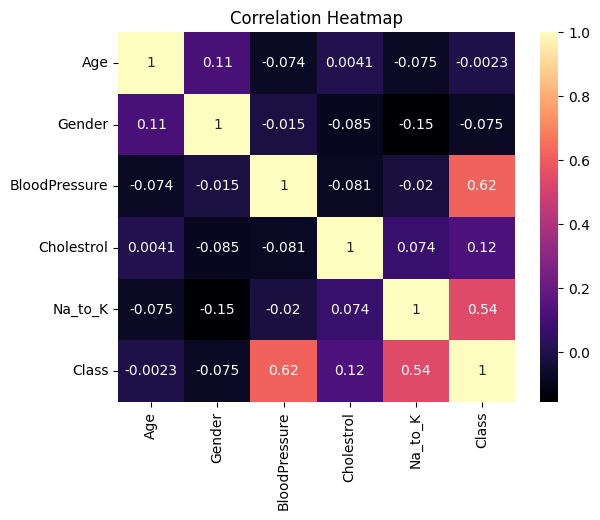

In [13]:
# correlation matrix
sns.heatmap(df.corr(), annot = True, cmap = 'magma')
plt.title("Correlation Heatmap")
plt.show()

In [15]:
# finding the best kernel
kernels_ = ['rbf','poly','sigmoid']

for i in kernels_:
    svm = SVC(kernel = i, probability=True, random_state=42)
    svm.fit(x_train, y_train)
    y_pred = svm.predict(x_test)

    # cross val score
    print(i,'=')
    print('accuracy_score: ',accuracy_score(y_test, y_pred))
    print('cross val score: ',cross_val_score(svm, scaler.transform(x), y, cv = 5,scoring='accuracy').mean())
    print('--'*50)

rbf =
accuracy_score:  0.9560439560439561
cross val score:  0.9626373626373625
----------------------------------------------------------------------------------------------------
poly =
accuracy_score:  0.9340659340659341
cross val score:  0.9340659340659341
----------------------------------------------------------------------------------------------------
sigmoid =
accuracy_score:  0.967032967032967
cross val score:  0.9406593406593406
----------------------------------------------------------------------------------------------------


> kernel used -> **<span style = 'color:orange'>'rbf'</span>**, due the highest cross_val_score, indicating best generalization

accuracy_score: 0.9560439560439561


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       0.95      1.00      0.97        18
           2       0.90      1.00      0.95        18
           3       0.95      1.00      0.97        19
           4       1.00      0.78      0.88        18

    accuracy                           0.96        91
   macro avg       0.96      0.96      0.95        91
weighted avg       0.96      0.96      0.95        91





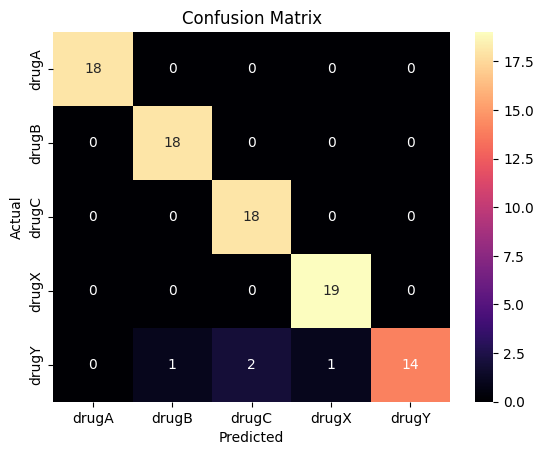

In [18]:
# model train
SVM = SVC(kernel = 'rbf', probability=True, random_state=42)
SVM.fit(x_train, y_train)
y_Pred = SVM.predict(x_test)

# evaluation
print('accuracy_score:', accuracy_score(y_test, y_Pred))
print('\n')
print(classification_report(y_test, y_Pred))
print('\n')
sns.heatmap(
    confusion_matrix(y_test, y_Pred),
    annot=True,
    fmt='d',
    cmap='magma',
    xticklabels=encoders['Class'].classes_,
    yticklabels=encoders['Class'].classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

drugA
AUC            : 1.000
Best Threshold : 0.837
----------------------------------------
drugB
AUC            : 0.998
Best Threshold : 0.501
----------------------------------------
drugC
AUC            : 1.000
Best Threshold : 0.937
----------------------------------------
drugX
AUC            : 1.000
Best Threshold : 0.844
----------------------------------------
drugY
AUC            : 1.000
Best Threshold : 0.335
----------------------------------------


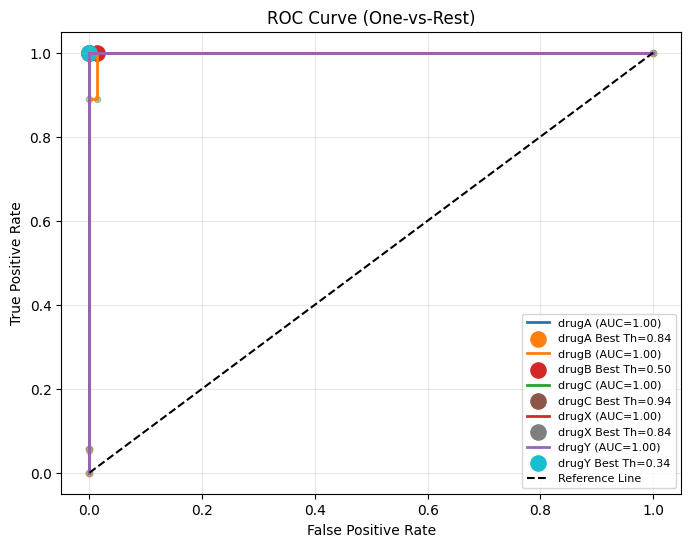

In [21]:
# ROC Curve and AUC Score

plt.figure(figsize=(8,6))

y_score = SVM.predict_proba(x_test)

classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

for i in range(len(classes)):

    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    auc = roc_auc_score(
        y_test_bin[:, i],
        y_score[:, i]
    )

    # Best threshold (Youden's J Statistic)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{encoders['Class'].classes_[i]} (AUC={auc:.2f})"
    )

    # Plot all threshold points
    plt.scatter(
        fpr,
        tpr,
        s=20,
        alpha=0.4
    )

    # Highlight best threshold
    plt.scatter(
        fpr[optimal_idx],
        tpr[optimal_idx],
        s=120,
        marker='o',
        label=f"{encoders['Class'].classes_[i]} Best Th={optimal_threshold:.2f}"
    )

    print(f"{encoders['Class'].classes_[i]}")
    print(f"AUC            : {auc:.3f}")
    print(f"Best Threshold : {optimal_threshold:.3f}")
    print("-"*40)

plt.plot([0,1],[0,1],'k--',label='Reference Line')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest)")
plt.legend(loc='lower right', fontsize=8)

plt.grid(alpha=0.3)
plt.show()

/Users/lucifer/Library/Python/3.9/lib/python/site-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


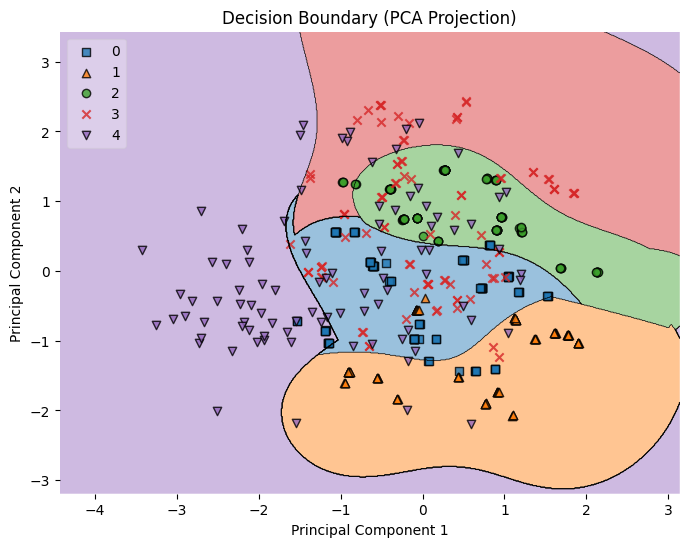

In [22]:
# decision boundry using PCA
pca = PCA(n_components=2)

x_pca = pca.fit_transform(scaler.transform(x))

svm_pca = SVC(kernel='rbf',random_state=42)
svm_pca.fit(x_pca, y)

plt.figure(figsize=(8,6))
plot_decision_regions(x_pca,y.to_numpy(),clf=svm_pca,legend=2)
plt.title("Decision Boundary (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()